# NLP Sentiment Analysis for US Election

Natural Language Processing is a subfield of Artificial Intelligence that enables computers to understand, analyze, and manipulate human language. This notebook discusses the prediction of U.S. election results based on Sentiment Analysis using tweets.

### What is Sentiment Analysis?
Sentiment analysis is a technique through which we can examine a text to figure out the sentiment such as the mood or mentality it represents. This technique is performed on textual data and classifies its sentiment as positive, negative, or neutral to assist businesses in tracking consumer needs and comprehending their needs accordingly.

It is a powerful technique with significant business implications such as predicting election results. We can forecast the outcome of the U.S. election by examining the sentiment behind the significant number of tweets by the general public toward participating candidates in the U.S. election.

### Steps to be followed:
1. Importing necessary libraries
2. Loading datasets
3. Data preprocessing
3. Exploratory Data Analysis
4. Sentiment Analysis
5. Conclusion

### Dataset: US Election 2020 Tweets | Kaggle

### Dataset features:

* **created_at:** Date and time of tweet posted
* **tweet_id:** Tweet's unique ID
* **tweet:** Full tweet text
* **likes:** Number of likes
* **retweet_count:** Number of retweets
* **source:** Utility used to post the tweet
* **user_id:** User ID of tweet creator
* **user_name:** Username of tweet creator
* **user_screen_name:** Screen name of tweet creator
* **user_description:** Self-description by tweet creator
* **user_join_date:** Join date of tweet creator
* **user_followers_count:** Followers count on tweet creator
* **user_location:** Address was given on tweeter's profile
* **lat:** Latitude parsed from user_location
* **long:** Longitude parsed from user_location
* **city:** City parsed from user_location
* **country:** Country parsed from user_location
* **state:** State parsed from user_location
* **state_code:** State code parsed from user_location
* **collected_at:** Date and time tweet data was mined from Twitter

Let's begin with the implementation.

## Importing main libraries:

In [1]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px

# Libraries for Sentiment Analysis
import re
import nltk
from nltk.corpus import stopwords
from nltk.corpus import wordnet
from nltk.stem import WordNetLemmatizer
from textblob import TextBlob
from wordcloud import WordCloud

# to avoid warnings
import warnings
warnings.filterwarnings('ignore')

* TextBlob: Used for tokenization as well as for finding the polarity and subjectivity of a text
* Regular expression (re): removes unnecessary symbols that do not provide any meaning such as @, comma, hashtags, *, etc.
* Natural Language Toolkit (nltk): removes stop words such as and, is, the, in, or, etc.

## Importing datasets
After importing all the important libraries, load the dataset.

In [2]:
# reading datasets
trump = pd.read_csv("hashtag_donaldtrump.csv", lineterminator='\n')
print(trump.head(3))

            created_at      tweet_id  \
0  2020-10-15 00:00:01  1.316529e+18   
1  2020-10-15 00:00:01  1.316529e+18   
2  2020-10-15 00:00:02  1.316529e+18   

                                               tweet  likes  retweet_count  \
0  #Elecciones2020 | En #Florida: #JoeBiden dice ...    0.0            0.0   
1  Usa 2020, Trump contro Facebook e Twitter: cop...   26.0            9.0   
2  #Trump: As a student I used to hear for years,...    2.0            1.0   

             source      user_id           user_name user_screen_name  \
0         TweetDeck  360666534.0  El Sol Latino News  elsollatinonews   
1  Social Mediaset   331617619.0             Tgcom24  MediasetTgcom24   
2   Twitter Web App    8436472.0              snarke           snarke   

                                    user_description  ...  \
0  🌐 Noticias de interés para latinos de la costa...  ...   
1  Profilo ufficiale di Tgcom24: tutte le notizie...  ...   
2  Will mock for food! Freelance writer, blogger,.

Let's have a look at all the features in this dataset.

In [3]:
# Display all the columns in the DataFrame
print(trump.columns)

Index(['created_at', 'tweet_id', 'tweet', 'likes', 'retweet_count', 'source',
       'user_id', 'user_name', 'user_screen_name', 'user_description',
       'user_join_date', 'user_followers_count', 'user_location', 'lat',
       'long', 'city', 'country', 'continent', 'state', 'state_code',
       'collected_at'],
      dtype='object')


Both, Donald Trump and Joe Biden datasets have same column features and format.

In [4]:
biden = pd.read_csv("hashtag_joebiden.csv", lineterminator='\n')
print(biden.head(2))

            created_at      tweet_id  \
0  2020-10-15 00:00:01  1.316529e+18   
1  2020-10-15 00:00:18  1.316529e+18   

                                               tweet  likes  retweet_count  \
0  #Elecciones2020 | En #Florida: #JoeBiden dice ...    0.0            0.0   
1  #HunterBiden #HunterBidenEmails #JoeBiden #Joe...    0.0            0.0   

             source      user_id           user_name user_screen_name  \
0         TweetDeck  360666534.0  El Sol Latino News  elsollatinonews   
1  Twitter for iPad  809904438.0         Cheri A. 🇺🇸     Biloximeemaw   

                                    user_description  ...  \
0  🌐 Noticias de interés para latinos de la costa...  ...   
1  Locked and loaded Meemaw. Love God, my family ...  ...   

  user_followers_count                 user_location       lat      long  \
0               1860.0  Philadelphia, PA / Miami, FL  25.77427 -80.19366   
1               6628.0                           NaN       NaN       NaN   

   city    

In [5]:
# Display all the columns in the DataFrame
print(biden.columns)


Index(['created_at', 'tweet_id', 'tweet', 'likes', 'retweet_count', 'source',
       'user_id', 'user_name', 'user_screen_name', 'user_description',
       'user_join_date', 'user_followers_count', 'user_location', 'lat',
       'long', 'city', 'country', 'continent', 'state', 'state_code',
       'collected_at'],
      dtype='object')


**Data Assessment:**
for example, studying the shape of data and what it tells, checking variables and their data types

In [6]:
print(trump.shape)
print(biden.shape)

(970919, 21)
(776886, 21)


From the output obtained, we can observe that the general public across different nations has tweeted more about Donald Trump as compared to Joe Biden, it can be good or bad!

Let's check the Trump data info

In [7]:
# Getting trump dataset information
trump.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 970919 entries, 0 to 970918
Data columns (total 21 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   created_at            970919 non-null  object 
 1   tweet_id              970919 non-null  float64
 2   tweet                 970919 non-null  object 
 3   likes                 970919 non-null  float64
 4   retweet_count         970919 non-null  float64
 5   source                970043 non-null  object 
 6   user_id               970919 non-null  float64
 7   user_name             970897 non-null  object 
 8   user_screen_name      970919 non-null  object 
 9   user_description      869651 non-null  object 
 10  user_join_date        970919 non-null  object 
 11  user_followers_count  970919 non-null  float64
 12  user_location         675957 non-null  object 
 13  lat                   445719 non-null  float64
 14  long                  445719 non-null  float64
 15  

Let's check the Biden data info

In [8]:
# Getting biden dataset information
biden.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 776886 entries, 0 to 776885
Data columns (total 21 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   created_at            776886 non-null  object 
 1   tweet_id              776886 non-null  float64
 2   tweet                 776886 non-null  object 
 3   likes                 776886 non-null  float64
 4   retweet_count         776886 non-null  float64
 5   source                776173 non-null  object 
 6   user_id               776886 non-null  float64
 7   user_name             776861 non-null  object 
 8   user_screen_name      776886 non-null  object 
 9   user_description      694877 non-null  object 
 10  user_join_date        776886 non-null  object 
 11  user_followers_count  776886 non-null  float64
 12  user_location         543092 non-null  object 
 13  lat                   355293 non-null  float64
 14  long                  355293 non-null  float64
 15  

## Data Preprocessing

Data Processing basically refers to the cleaning, transforming, and integrating of data in order to make it ready for analysis.

It is the most important step in an analysis to achieve accurate results with increased quality and reliability as the raw data can be inconsistent or incomplete in formatting.

This process involves tasks such as:

**Performing data integration and transformation:**\
After data cleaning, it is preferable to convert it into formats that are easy to read and understand by software applications and algorithms. You can integrate and transform your data using the following way:

* Condensing datasets to reduce the total amount of data by concatenating both datasets for easier analysis using the pandas' concat function.

In [9]:
# creating a new column 'candidate' todifferentiate
# between tweets of Trump and Biden upon concatination
trump['candidate'] = 'trump'

# biden dataframe
biden['candidate'] = 'biden'

# combining the dataframes
data = pd.concat([trump, biden])

# FInal data shape
print('Final Data Shape :', data.shape)

# View the first 2 rows
print("\nFirst 2 rows:")
print(data.head(3))

Final Data Shape : (1747805, 22)

First 2 rows:
            created_at      tweet_id  \
0  2020-10-15 00:00:01  1.316529e+18   
1  2020-10-15 00:00:01  1.316529e+18   
2  2020-10-15 00:00:02  1.316529e+18   

                                               tweet  likes  retweet_count  \
0  #Elecciones2020 | En #Florida: #JoeBiden dice ...    0.0            0.0   
1  Usa 2020, Trump contro Facebook e Twitter: cop...   26.0            9.0   
2  #Trump: As a student I used to hear for years,...    2.0            1.0   

             source      user_id           user_name user_screen_name  \
0         TweetDeck  360666534.0  El Sol Latino News  elsollatinonews   
1  Social Mediaset   331617619.0             Tgcom24  MediasetTgcom24   
2   Twitter Web App    8436472.0              snarke           snarke   

                                    user_description  ...  \
0  🌐 Noticias de interés para latinos de la costa...  ...   
1  Profilo ufficiale di Tgcom24: tutte le notizie...  ...   
2 

## Data Cleaning:
Dropping missing values

In [10]:
# dropping null values if they exist
data.dropna(inplace=True)

**Check the unique Country name where the mostly tweet are generated**

In [11]:
data['country'].value_counts()

country
United States of America    182382
United Kingdom               31869
India                        20931
France                       19996
Germany                      18534
Canada                       16250
The Netherlands               8491
Australia                     8330
Spain                         5254
Brazil                        4211
Pakistan                      3704
Italy                         2966
Ireland                       2587
Bangladesh                    2036
Mexico                        1972
Belgium                       1962
Nigeria                       1848
South Africa                  1648
United Arab Emirates          1521
Switzerland                   1494
Peru                          1031
Lebanon                       1002
Argentina                      872
Ecuador                        824
Colombia                       565
Honduras                       508
Venezuela                      431
New Zealand                    384
Poland      

An important thing to note while exploring the data is that "United States of America" and "US" in the country column are treated as different nations in the dataset which is a major problem. Therefore, we can assign a common term "US" to treat it as one country.

In [12]:
data['country'] = data['country'].replace({'United States of America': "US",
                                           'United States': "US"})

## Exploratory Data Analysis

Exploratory Data Analysis (EDA) is a method used to analyze and investigate data sets and summarize their main characteristics, often employing data visualization methods.

**Tweets for Candidates**\
So, here we check the number of tweets received for each of them using a bar graph.

In [13]:
# Group the data by 'candidate' and count the
# number of tweets for each candidate
tweets_count = data.groupby('candidate')['tweet'].count().reset_index()

# Interactive bar chart
fig = px.bar(tweets_count, x='candidate', y='tweet', color='candidate',
             color_discrete_map={'Trump': 'pink', 'Biden': 'blue'},
             labels={'candidate': 'Candidates', 'tweet': 'Number of Tweets'},
             title='Tweets for Candidates')

# Show the chart
fig.show()

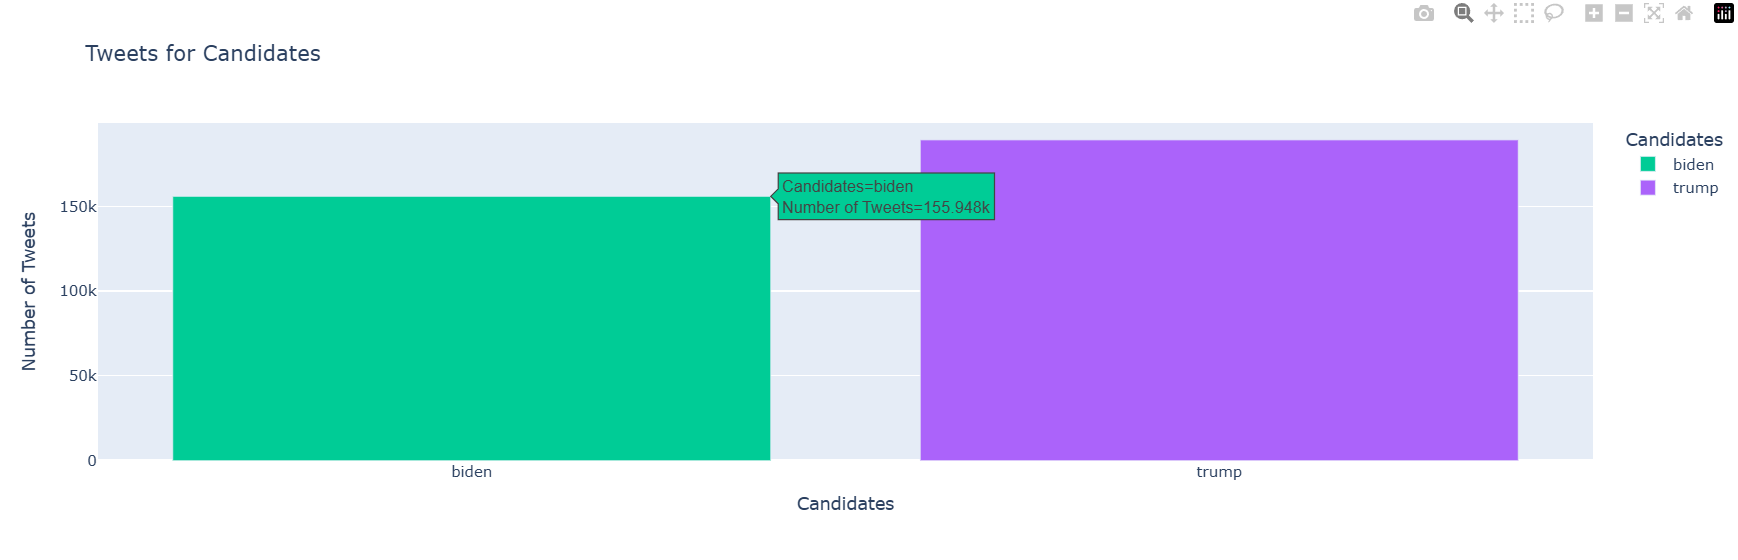

Interpretation: Upon studying the graph, we can say that Donald Trump is the most tweeted about by the general public as compared to Joe Biden.

**Comparison of Likes**

In [14]:
# Interactive bar chart
likes_comparison = data.groupby('candidate')['likes'].sum().reset_index()
fig = px.bar(likes_comparison, x='candidate', y='likes', color='candidate',
             color_discrete_map={'Trump': 'blue', 'Biden': 'green'},
             labels={'candidate': 'Candidate', 'likes': 'Total Likes'},
             title='Comparison of Likes')

# Update the layout with a black theme
fig.update_layout(plot_bgcolor='black',
                  paper_bgcolor='black', font_color='white')

# Show the chart
fig.show()

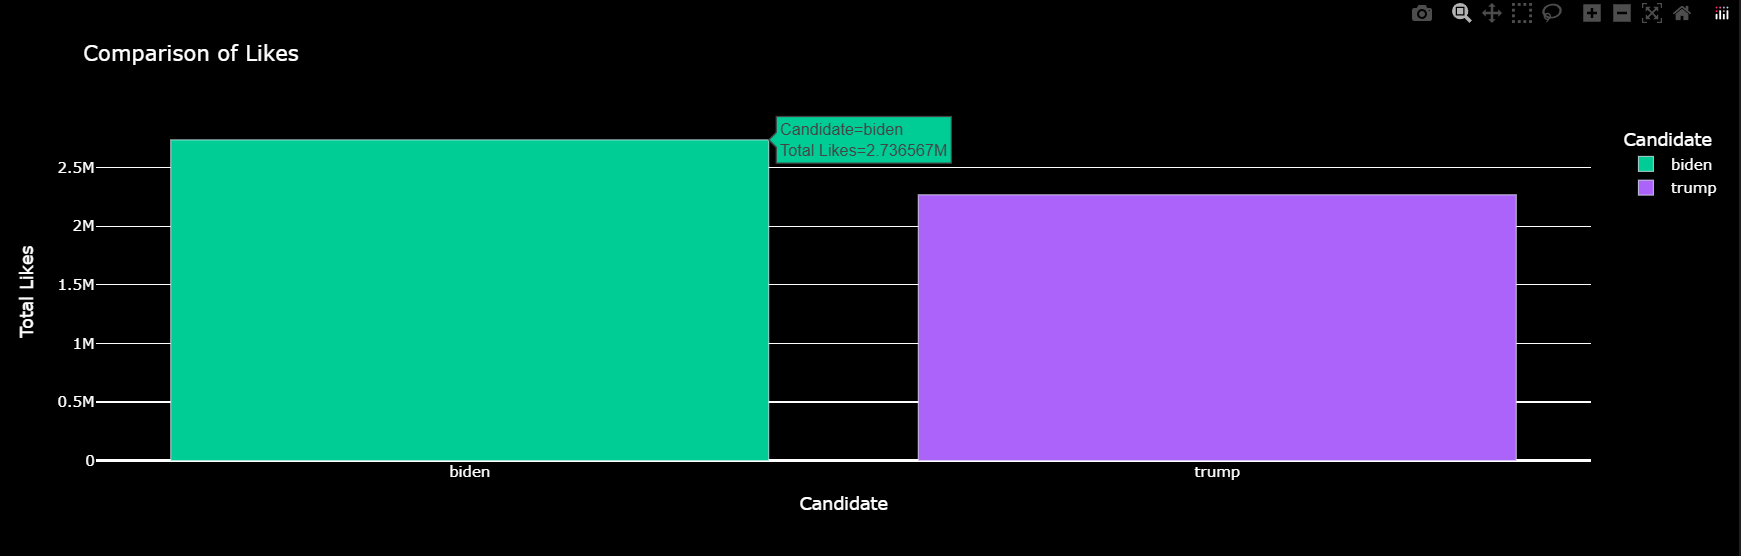

Interpretation: The public has tweeted the most about Donald Trump however the number of likes are high for Joe Biden which definitely indicates liking towards Biden.

**Top10 Country-wise tweets Counts**\
So, let's find out the top 10 countries that are most active in tweeting during the elections.

In [15]:
# Top10 Countrywise tweets Counts
top10countries = data.groupby('country')['tweet'].count(
).sort_values(ascending=False).reset_index().head(10)
# top10countries

# Interactive bar chart
fig = px.bar(top10countries, x='country', y='tweet',
             template='plotly_dark',
             color_discrete_sequence=px.colors.qualitative.Dark24_r,
             title='Top10 Countrywise tweets Counts')

# To view the graph
fig.show()

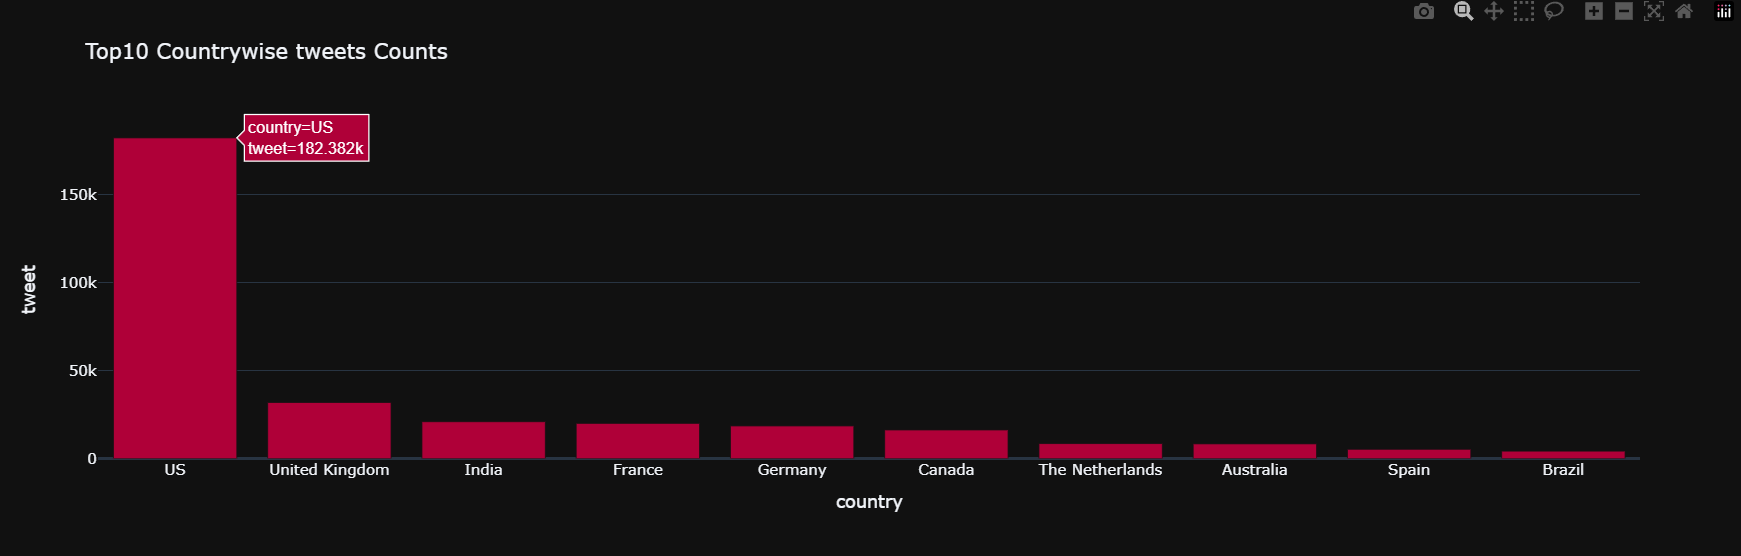

**Tweet Counts for Each Candidate in the Top 10 Countries**\
Now, let us find out the number of tweets done for each candidate by all the countries.

In [16]:
# the number of tweets done for each
# candidate by all the countries.
tweet_df = data.groupby(['country', 'candidate'])[
    'tweet'].count().reset_index()

# Candidate for top 10 country tweet
tweeters = tweet_df[tweet_df['country'].isin(top10countries.country)]

# Plot for tweet counts for each candidate
# in the top 10 countries
fig = px.bar(tweeters, x='country', y='tweet', color='candidate',
             labels={'country': 'Country', 'tweet': 'Number of Tweets',
                     'candidate': 'Candidate'},
             title='Tweet Counts for Each Candidate in the Top 10 Countries',
             template='plotly_dark',
             barmode='group')

# Show the chart
fig.show()

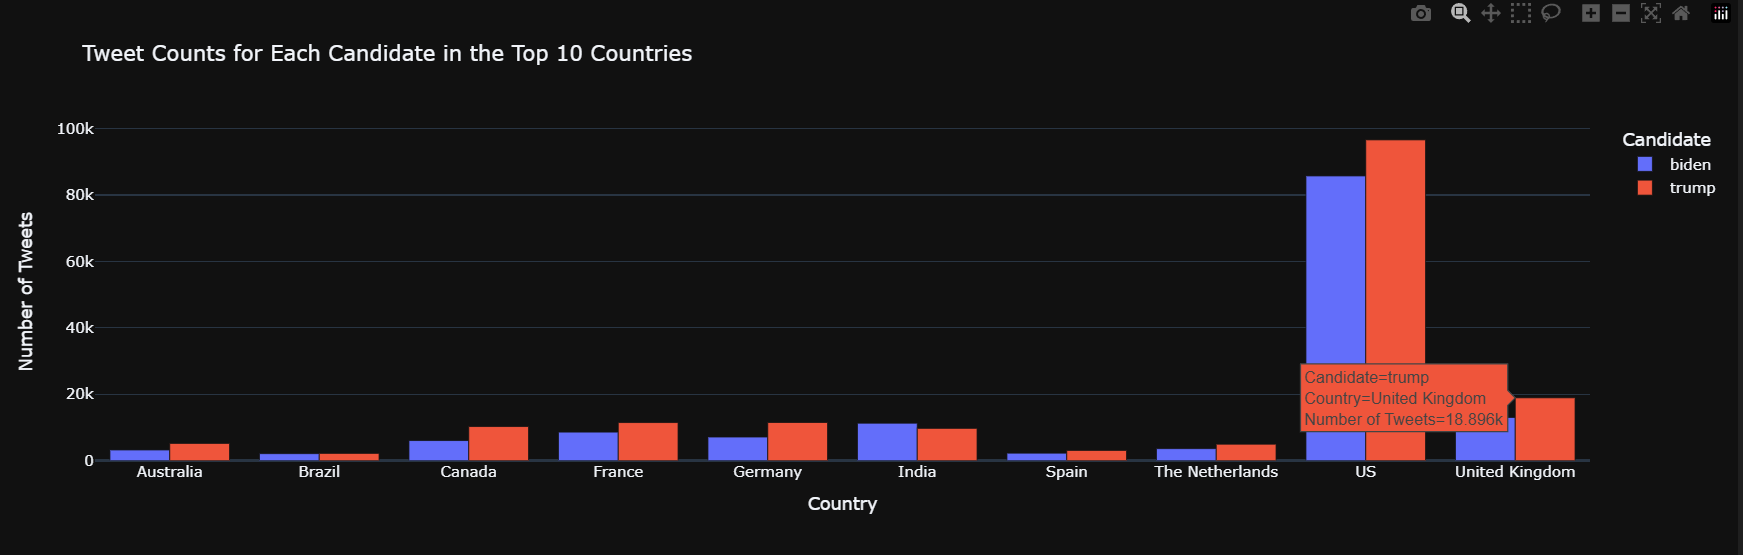

Interpretation: All the countries are tweeting the most about Trump. However, India is talking more about Joe Biden.

## Sentiment Analysis for prediction of election results

We shall only take into account US citizens' opinions here, as they are a crucial deciding factor in who becomes the US president.

In [17]:
def clean(text):
    # Remove URLs
    text = re.sub(r'https?://\S+|www\.\S+', '', str(text))

    # Convert text to lowercase
    text = text.lower()

    # Replace anything other than alphabets a-z with a space
    text = re.sub('[^a-z]', ' ', text)

    # Split the text into single words
    text = text.split()

    # Initialize WordNetLemmatizer
    lm = WordNetLemmatizer()

    # Lemmatize words and remove stopwords
    text = [lm.lemmatize(word) for word in text if word not in set(
        stopwords.words('english'))]

    # Join the words back into a sentence
    text = ' '.join(word for word in text)

    return text

**Get polarity, subjectivity, and Analysis**\
Now, let's create a function to get polarity, subjectivity, and Analysis function to fetch sentiments from the data.

In [18]:
def getpolarity(text):
    return TextBlob(text).sentiment.polarity

def getsubjectivity(text):
    return TextBlob(text).sentiment.subjectivity

def getAnalysis(score):
    if score < 0:
        return 'negative'
    elif score == 0:
        return 'neutral'
    else:
        return 'positive'

**Donald Trump tweet sentiment analysis**\
Note: We are considering the data of only, the United States of America because that will be a major factor in predicting the results.

In [19]:
trump_tweets = data[data['candidate'] == 'trump']

# taking only U.S. country data
trump_tweets = trump_tweets.loc[trump_tweets.country == 'US']
trump_tweets = trump_tweets[['tweet']]
print(trump_tweets.head())

                                                tweet
2   #Trump: As a student I used to hear for years,...
4   You get a tie! And you get a tie! #Trump ‘s ra...
11  In 2020, #NYPost is being #censorship #CENSORE...
12  #Trump #PresidentTrump #Trump2020LandslideVict...
22  #Trump: Nobody likes to tell you this, but som...


Now, we apply the clean function to get cleaned text from tweets.

In [20]:
trump_tweets['cleantext'] = trump_tweets['tweet'].apply(clean)
print(trump_tweets.head())

                                                tweet  \
2   #Trump: As a student I used to hear for years,...   
4   You get a tie! And you get a tie! #Trump ‘s ra...   
11  In 2020, #NYPost is being #censorship #CENSORE...   
12  #Trump #PresidentTrump #Trump2020LandslideVict...   
22  #Trump: Nobody likes to tell you this, but som...   

                                            cleantext  
2   trump student used hear year ten year heard ch...  
4                    get tie get tie trump rally iowa  
11  nypost censorship censored twitter manipulate ...  
12  trump presidenttrump trump landslidevictory tr...  
22  trump nobody like tell farmer better way worki...  


**Subjectivity**\
To know if the sentence is subjective or objective. Subjective means sentence refers to a personal opinion and not facts whereas objective means facts

Now, obtaining subjectivity for Trump's tweets.

In [21]:
trump_tweets['subjectivity'] = trump_tweets['cleantext'].apply(getsubjectivity)

**Polarity**

It is represented by a float value that lies between -1 and 1, where 1 = positive sentiment, -1 = negative sentiment

Getting the polarity of the data now.

In [22]:
trump_tweets['polarity'] = trump_tweets['cleantext'].apply(getpolarity)

**Sentiments**

Now, classifying the sentiments as positive, negative or neutral.

In [23]:
trump_tweets['analysis'] = trump_tweets['polarity'].apply(getAnalysis)
trump_tweets.head()

,tweet,cleantext,subjectivity,polarity,analysis
2,"#Trump: As a student I used to hear for years,...",trump student used hear year ten year heard ch...,0.333333,0.333333,positive
4,You get a tie! And you get a tie! #Trump ‘s ra...,get tie get tie trump rally iowa,0.000000,0.000000,neutral
11,"In 2020, #NYPost is being #censorship #CENSORE...",nypost censorship censored twitter manipulate ...,0.678571,-0.148810,negative
12,#Trump #PresidentTrump #Trump2020LandslideVict...,trump presidenttrump trump landslidevictory tr...,0.750000,0.500000,positive
22,"#Trump: Nobody likes to tell you this, but som...",trump nobody like tell farmer better way worki...,0.595238,0.261905,positive


Let's see the distribution of positive, negative and neutral sentiments.

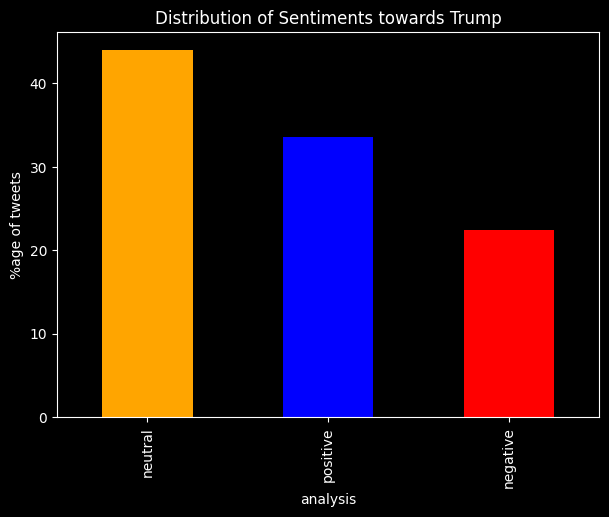

In [24]:
# how much data is positive/negetive/neutral
plt.style.use('dark_background')  # Adding black theme

# Define colors for each bar
colors = ['orange', 'blue', 'red']

plt.figure(figsize=(7, 5))
(trump_tweets.analysis.value_counts(normalize=True) * 100).plot.bar(color=colors)
plt.ylabel("%age of tweets")
plt.title("Distribution of Sentiments towards Trump")
plt.show()

Now, plotting Word Cloud to quickly identify the most important themes or topics in the text and understand the overall sentiment or tone of the tweets.

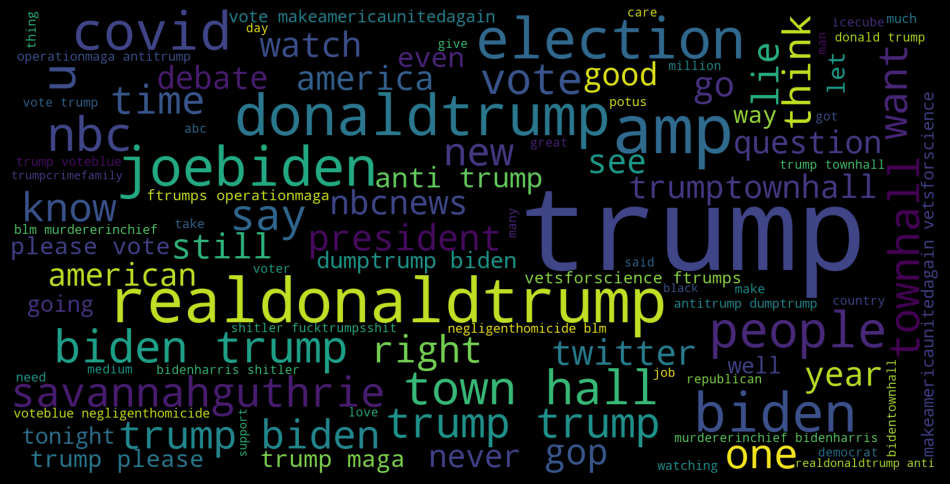

In [25]:
import matplotlib.pyplot as plt
from wordcloud import WordCloud, STOPWORDS

def word_cloud(wd_list): 
	stopwords = set(STOPWORDS)
	all_words = ' '.join(wd_list)
	wordcloud = WordCloud(background_color='black', 
						stopwords=stopwords, 
						width=1600, height=800, max_words=100, max_font_size=200, 
						colormap="viridis").generate(all_words) 
	plt.figure(figsize=(12, 10)) 
	plt.axis('off') 
	plt.imshow(wordcloud) 

word_cloud(trump_tweets['cleantext'][:5000])


**Joe Biden's Twitter sentiment analysis**

In [26]:
biden_tweets = data[data['candidate'] == 'biden']
biden_tweets = biden_tweets.loc[biden_tweets.country == 'US']
biden_tweets = biden_tweets[['tweet']]
biden_tweets

,tweet
6,"In 2020, #NYPost is being #censorship #CENSORE..."
17,"Comments on this? ""Do Democrats Understand how..."
25,@RealJamesWoods #BidenCrimeFamily #JoeBiden #H...
29,Come on @ABC PLEASE DO THE RIGHT THING. Move t...
34,#realDonaldTrump addresses #JoeBiden and #Hunt...
...,...
776836,"#Biden 🗽🇺🇸👍🏽 | Images 📷 @ Santa Maria, CA. | ..."
776845,Will #criticalRaceTheory become ubiquitous in ...
776847,You moving near #Biden 🤔 https://t.co/1F6i1YIJ2P
776861,#election #2020Elections #trump #biden https:/...


Similarly, we apply all the functions for Joe Biden now.

In [27]:
biden_tweets['cleantext']=biden_tweets['tweet'].apply(clean)
biden_tweets.head()

,tweet,cleantext
6,"In 2020, #NYPost is being #censorship #CENSORE...",nypost censorship censored twitter manipulate ...
17,"Comments on this? ""Do Democrats Understand how...",comment democrat understand ruthless china chi...
25,@RealJamesWoods #BidenCrimeFamily #JoeBiden #H...,realjameswoods bidencrimefamily joebiden hunte...
29,Come on @ABC PLEASE DO THE RIGHT THING. Move t...,come abc please right thing move biden town ha...
34,#realDonaldTrump addresses #JoeBiden and #Hunt...,realdonaldtrump address joebiden hunterbiden c...


Similarly, repeating the steps for Joe Biden analysis.

In [28]:
biden_tweets['subjectivity'] = biden_tweets['cleantext'].apply(getsubjectivity)
biden_tweets['polarity'] = biden_tweets['cleantext'].apply(getpolarity)
biden_tweets['analysis'] = biden_tweets['polarity'].apply(getAnalysis)
biden_tweets.head()

,tweet,cleantext,subjectivity,polarity,analysis
6,"In 2020, #NYPost is being #censorship #CENSORE...",nypost censorship censored twitter manipulate ...,0.678571,-0.148810,negative
17,"Comments on this? ""Do Democrats Understand how...",comment democrat understand ruthless china chi...,1.000000,-1.000000,negative
25,@RealJamesWoods #BidenCrimeFamily #JoeBiden #H...,realjameswoods bidencrimefamily joebiden hunte...,0.000000,0.000000,neutral
29,Come on @ABC PLEASE DO THE RIGHT THING. Move t...,come abc please right thing move biden town ha...,0.178571,0.078571,positive
34,#realDonaldTrump addresses #JoeBiden and #Hunt...,realdonaldtrump address joebiden hunterbiden c...,0.000000,0.000000,neutral


Now, we find out the distribution of sentiments in the dataset to know which sentiment holds the most values and how it will affect the election results.

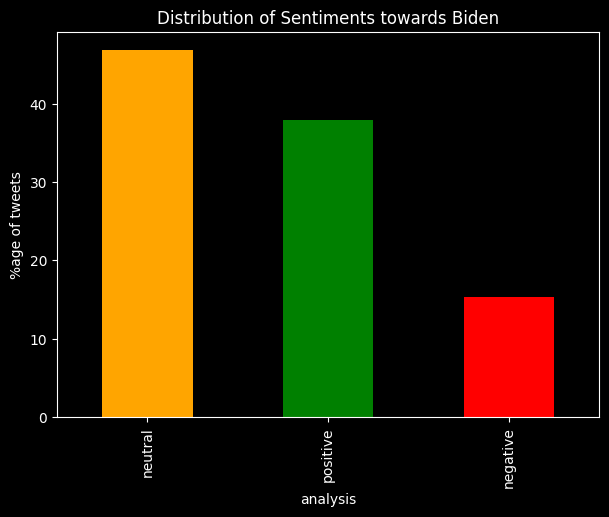

In [29]:
# how much data is positive/negetive/neutral
plt.style.use('dark_background')

# Define colors for each bar
colors = ['orange', 'green', 'red']

plt.figure(figsize=(7, 5))
(biden_tweets.analysis.value_counts(normalize=True) * 100).plot.bar(color=colors)
plt.ylabel("%age of tweets")
plt.title("Distribution of Sentiments towards Biden")
plt.show()

Now, plotting the Word Cloud for the Joe Biden dataset.

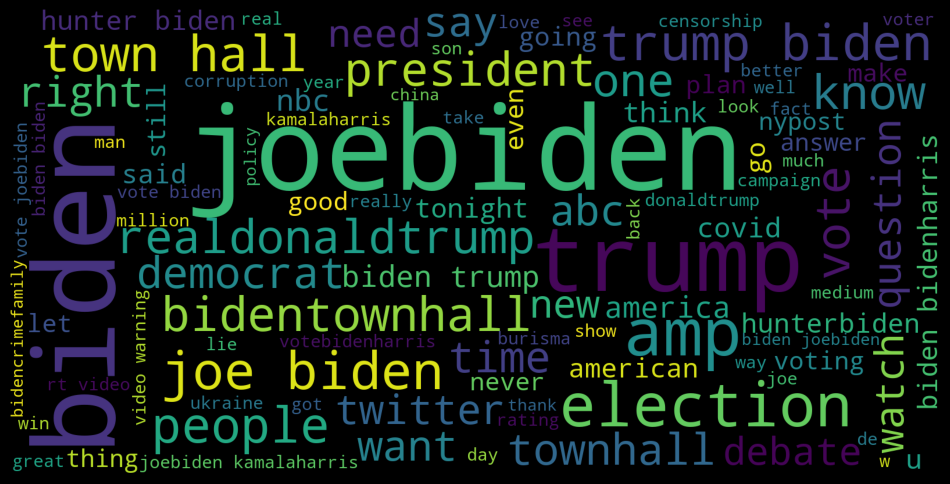

In [30]:
word_cloud(biden_tweets['cleantext'][:5000])

let us now analyze the sentiments to predict the results for Donald Trump

In [31]:
trump_tweets.analysis.value_counts(normalize=True)*100


analysis
neutral     43.995156
positive    33.566890
negative    22.437954
Name: proportion, dtype: float64

Now, analyze tweets for Joe Biden

In [32]:
biden_tweets.analysis.value_counts(normalize=True)*100


analysis
neutral     46.831856
positive    37.880131
negative    15.288013
Name: proportion, dtype: float64

## Conclusion:
let's analyze what each sentiment's percentage represents and its implications on the result.

* **Positive Sentiment:** Positive tweets about Biden outnumber positive tweets about Trump: Biden's tweets have a higher percentage of positive feelings (36.43%) than Trump's ( 33.99%). This shows that Twitter users are responding more favorably to Biden.

* **Neutral Sentiment:** Trump receives more neutral sentiments: In contrast, Trump receives slightly more neutral sentiments (43.22%) in comparison to Biden (46.83%) in his tweets. This may indicate that Trump's tweets are more likely to be seen as neutral or impersonal, leading to a higher neutral sentiment rate.

* **Negative Sentiment:** Trump gets more unfavorable reactions: While both candidates have received criticism, Trump's tweets have a greater percentage of unfavorable reactions (22.78%) than Biden's (16.79%). This implies that there may have been more opposition to Trump's tweets on Twitter.

With respect to the U.S. voters, it was highlighted a lot of times that Trump was the most talked about and tweeted about among people however, Trump has received more negative comments as compared to Joe Biden. As a result, **Joe Biden won the 2020 elections** which is a proven fact. However, overall, the competition was close as shown by the data.